In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.plot_utils import setup
from analysis.utils.truth import get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
)

In [3]:
setup()

In [110]:
# path = Path("/Users/tboeckh/tmp/pinpoint.root")
# path = Path("/Users/tboeckh/tmp/10001_000.root")
run = 10001
chunk = 0
path = get_root_path() / f"{run}/{run}_{chunk:03d}.root"
root_file = uproot.open(path)

df = root_file["Hits/pixelHits"].arrays(library="pd")
geom = root_file["geometry"].arrays(library="np")
truth_df = root_file["event"].arrays(library="pd")
scint_df = ak.to_dataframe(
    root_file["Hits/scintHits"].arrays(library="ak"), how="outer"
)


In [66]:
# path = Path("/Users/tboeckh/tmp/pinpoint.root")
# root_file = uproot.open(path)

# # truth neutrino
# truth_columns = ["evtID", "initPDG", "initX", "initY", "initZ", "initE"]
# truth_df = root_file["event"].arrays(truth_columns, library="pd")
# truth_df.rename(
#     columns={
#         "evtID": "event_id",
#         "initPDG": "pdg_nu",
#         "initE": "E_nu",
#         "initX": "vx",
#         "initY": "vy",
#         "initZ": "vz",
#     },
#     inplace=True,
# )

# # truth lepton
# primaries_columns = ["evtID", "trackID", "PDG", "E", "Px", "Py", "Pz"]
# primaries_df = root_file["primaries"].arrays(primaries_columns, library="pd")
# primaries_df.query("trackID == 1", inplace=True)
# primaries_df = primaries_df[[i for i in primaries_df.columns if i != "trackID"]]
# primaries_df.rename(
#     columns={
#         "evtID": "event_id",
#         "E": "E_lepton",
#         "PDG": "pdg_lepton",
#         "Px": "px_lepton",
#         "Py": "py_lepton",
#         "Pz": "pz_lepton",
#     },
#     inplace=True,
# )

# if len(truth_df) != len(primaries_df):
#     raise ValueError("Dataframes should have same length!")

# truth_df = pd.merge(truth_df, primaries_df, left_on="event_id", right_on="event_id")
# truth_df.head()

In [69]:
# # geometry
# geom_columns = ["pixel_Xpos", "pixel_Ypos", "pixel_Zpos"]
# geom = root_file["geometry"].arrays(geom_columns, library="np")

# # pixel hits
# columns = ["event_id", "hit_rowID", "hit_colID", "hit_layerID", "hit_pdgc", "hit_edep"]
# df: pd.DataFrame = ak.to_dataframe(
#     root_file["Hits/pixelHits"].arrays(columns, library="ak"),
#     how="outer",
# )

# # remove hits that are outside of the detector range
# max_row_index = 8596
# max_col_index = 12788
# df.query(f"hit_rowID < {max_row_index} and hit_colID < {max_col_index}", inplace=True)

# # map pixel indices to positions
# # df["x"] = df.apply(lambda row: geom["pixel_Xpos"][0][int(row["hit_colID"])], axis=1)
# # df["y"] = df.apply(lambda row: geom["pixel_Ypos"][0][int(row["hit_rowID"])], axis=1)
# # df["z"] = df.apply(lambda row: geom["pixel_Zpos"][0][int(row["hit_layerID"])], axis=1)
# df.loc[:, "x"] = geom["pixel_Xpos"][0][df["hit_colID"].astype(int).values]
# df.loc[:, "y"] = geom["pixel_Ypos"][0][df["hit_rowID"].astype(int).values]
# df.loc[:, "z"] = geom["pixel_Zpos"][0][df["hit_layerID"].astype(int).values]

# df.head()

In [130]:
def get_rebinned_df(
    hits_df: pd.DataFrame,
    old_geometry: Geometry,
    new_geometry: Geometry,
    layer_var: str = "hit_layerID",
    pixel_x_var: str = "hit_colID",
    pixel_y_var: str = "hit_rowID",
    energy_var: str = "hit_edep",
) -> pd.DataFrame:
    """
    Get hits with different bin size.
    This is useful to cluster pixels and reduce total number of pixels.
    """
    x_bin_factor = new_geometry.pixel_x_size / old_geometry.pixel_x_size
    y_bin_factor = new_geometry.pixel_y_size / old_geometry.pixel_y_size
    hits_resampled = hits_df.copy()
    hits_resampled.loc[:, "new_pixel_x"] = (
        hits_df[pixel_x_var].values // x_bin_factor
    ).astype(int)
    hits_resampled.loc[:, "new_pixel_y"] = (
        hits_df[pixel_y_var].values // y_bin_factor
    ).astype(int)

    hits_resampled["from_muon"] = 0
    hits_resampled.loc[hits_resampled["hit_pdgc"].abs() == 13, "from_muon"] = 1

    hits_resampled["from_electron"] = 0
    hits_resampled.loc[hits_resampled["hit_pdgc"].abs() == 11, "from_electron"] = 1

    aggregator_dict = {
        "energy": (energy_var, "sum"),
        "n_hits": (energy_var, "count"),
        "from_muon": ("from_muon", "any"),
        "from_electron": ("from_electron", "any"),
    }
    # if "from_muon" in hits_df.columns:
    #     aggregator_dict["from_muon"] = ("from_muon", "any")
    # if "from_electron" in hits_df.columns:
    #     aggregator_dict["from_electron"] = ("from_electron", "any")

    resampled = (
        hits_resampled.groupby(["event_id", layer_var, "new_pixel_x", "new_pixel_y"])
        .agg(**aggregator_dict)
        .reset_index()
    )

    # if "from_muon" in resampled.columns and "from_electron" in resampled.columns:
    resampled["hit_label"] = 0
    resampled.loc[resampled["from_muon"] == 1, "hit_label"] = 1
    resampled.loc[resampled["from_electron"] == 1, "hit_label"] = 2

    resampled.rename(
        columns={"new_pixel_x": "pixel_x", "new_pixel_y": "pixel_y"}, inplace=True
    )

    columns = [
        "event_id",
        "hit_layerID",
        "pixel_x",
        "pixel_y",
        "hit_label",
        "from_muon",
        "from_electron",
    ]
    # "energy", "n_hits",

    return resampled[columns]

In [131]:
run = 10001
chunk = 0
parquet_path = get_parquet_path() / f"{run}"
df = pd.read_parquet(parquet_path / f"{run}_{chunk}_hits.parq")
truth_df = pd.read_parquet(parquet_path / f"{run}_{chunk}_truth.parq")

In [132]:
pixel_size = 200  # in um
geo = Geometry()
new_geo = get_rebinned_geometry(pixel_size=pixel_size * um, old_geometry=geo)
new_df = get_rebinned_df(hits_df=df, old_geometry=geo, new_geometry=new_geo)

In [134]:
new_df["from_muon"].value_counts()

from_muon
False    11699040
True       103257
Name: count, dtype: int64

In [135]:
new_df["from_electron"].value_counts()

from_electron
True     6653556
False    5148741
Name: count, dtype: int64

In [136]:
new_df["hit_label"].value_counts()

hit_label
2    6653556
0    5047682
1     101059
Name: count, dtype: int64

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_20110/2660885021.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_df.loc[:, "color"] = "black"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_20110/2660885021.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_df.loc[:, "size"] = 1
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_20110/2660885021.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an unde

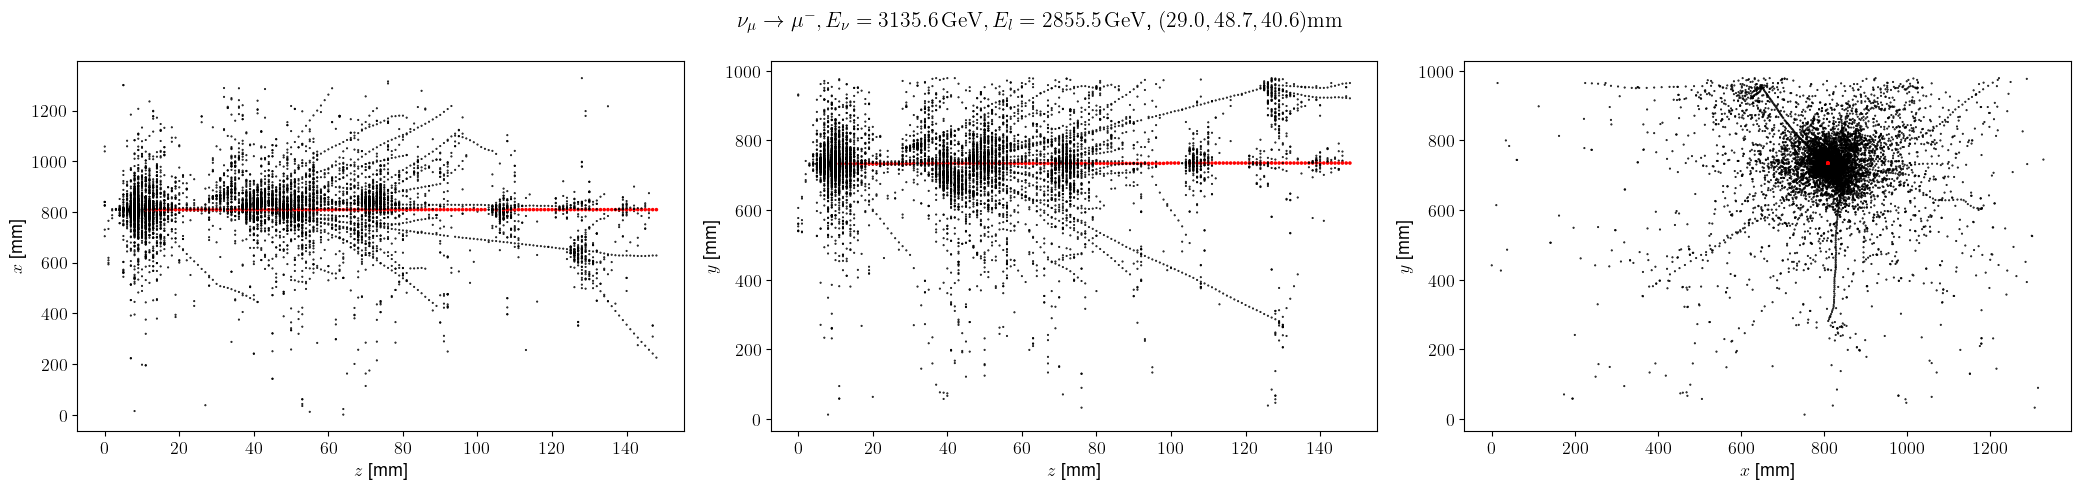

In [140]:
event_id = 0
event_df = new_df.query("event_id == @event_id")
event_truth_df = truth_df.query("event_id == @event_id")
truth = get_truth_particle(event_truth_df)

# event_df.loc[:, "color"] = event_df["hit_pdgc"].apply(get_color_from_pdg)
event_df.loc[:, "color"] = "black"
event_df.loc[event_df["hit_label"] == 1, "color"] = "red"
# event_df.loc[event_df["hit_label"] == 2, "color"] = "red"

event_df.loc[:, "size"] = 1
event_df.loc[event_df["hit_label"] == 1, "size"] = 10
event_df.loc[event_df["hit_label"] == 2, "size"] = 1

xvar = "pixel_x"
yvar = "pixel_y"
zvar = "hit_layerID"

fig, ax = plt.subplots(ncols=3, figsize=(21, 5))

# zx
ax[0].scatter(
    event_df[zvar], event_df[xvar], c=event_df["color"], marker=".", s=event_df["size"]
)
# ax[0].scatter(
#     event_truth_df["vz"],
#     event_truth_df["vx"],
#     c="red",
#     marker="x",
#     label="truth Vertex",
#     s=10,
# )
ax[0].set_xlabel(r"$z$ [mm]")
ax[0].set_ylabel(r"$x$ [mm]")

# zy
ax[1].scatter(
    event_df[zvar], event_df[yvar], c=event_df["color"], marker=".", s=event_df["size"]
)
# ax[1].scatter(
#     event_truth_df["vz"],
#     event_truth_df["vy"],
#     c="red",
#     marker="x",
#     label="truth Vertex",
#     s=10,
# )
ax[1].set_xlabel(r"$z$ [mm]")
ax[1].set_ylabel(r"$y$ [mm]")

# xy
ax[2].scatter(
    event_df[xvar], event_df[yvar], c=event_df["color"], marker=".", s=event_df["size"]
)
# ax[2].scatter(
#     event_truth_df["vx"],
#     event_truth_df["vy"],
#     c="red",
#     marker="x",
#     label="truth Vertex",
#     s=10,
# )
ax[2].set_xlabel(r"$x$ [mm]")
ax[2].set_ylabel(r"$y$ [mm]")

fig.suptitle(truth.get_latex_title())


# for i in event_df["hit_pdgc"].unique():
#     color = get_color_from_pdg(i)
#     label = get_label_from_pdg(i)
#     if color != "white":
#         ax[0].scatter(
#             [],
#             [],
#             c=color,
#             label=f"${label}$",
#             s=10,
#         )

ax[0].legend()

plt.tight_layout()
plt.show()

In [95]:
path = Path("/Users/tboeckh/tmp/pinpoint.root")
run = 10001
chunk = 0
root_file = uproot.open(path)

# geometry
geom_columns = ["pixel_Xpos", "pixel_Ypos", "pixel_Zpos"]
geom = root_file["geometry"].arrays(geom_columns, library="np")

# truth
truth_columns = ["evtID", "initPDG", "initX", "initY", "initZ", "initE"]
truth_df = root_file["event"].arrays(truth_columns, library="pd")
truth_df.rename(
    columns={
        "evtID": "event_id",
        "initPDG": "pdg_nu",
        "initE": "E_nu",
        "initX": "vx",
        "initY": "vy",
        "initZ": "vz",
    },
    inplace=True,
)

# truth lepton
primaries_columns = ["evtID", "trackID", "PDG", "E", "Px", "Py", "Pz"]
primaries_df = root_file["primaries"].arrays(primaries_columns, library="pd")
primaries_df.query("trackID == 1", inplace=True)
primaries_df = primaries_df[[i for i in primaries_df.columns if i != "trackID"]]
primaries_df = primaries_df.rename(
    columns={
        "evtID": "event_id",
        "E": "E_lepton",
        "PDG": "pdg_lepton",
        "Px": "px_lepton",
        "Py": "py_lepton",
        "Pz": "pz_lepton",
    }
)

if len(truth_df) != len(primaries_df):
    raise ValueError("Dataframes should have same length!")

truth_df = pd.merge(truth_df, primaries_df, left_on="event_id", right_on="event_id")

# pixel hits
columns = [
    "event_id",
    "hit_rowID",
    "hit_colID",
    "hit_layerID",
    "hit_pdgc",
    "hit_edep",
    "hit_fromPrimaryLepton",
]
df: pd.DataFrame = ak.to_dataframe(
    root_file["Hits/pixelHits"].arrays(columns, library="ak"),
    how="outer",
)

# remove hits that are outside of the detector range
max_row_index = 8596
max_col_index = 12788
df.query(f"hit_rowID < {max_row_index} and hit_colID < {max_col_index}", inplace=True)

# map pixel indices to positions
df.loc[:, "x"] = geom["pixel_Xpos"][0][df["hit_colID"].astype(int).values]
df.loc[:, "y"] = geom["pixel_Ypos"][0][df["hit_rowID"].astype(int).values]
df.loc[:, "z"] = geom["pixel_Zpos"][0][df["hit_layerID"].astype(int).values]

In [96]:
df.head()

event_id  hit_rowID  hit_colID  hit_layerID      hit_pdgc  \
entry subentry                                                              
0     0             4000     4065.0     6106.0          3.0  2.212000e+03   
      1             4000     4505.0     6378.0          5.0  4.294967e+09   
      2             4000     4534.0     6333.0          5.0  2.212000e+03   
      3             4000     4010.0     6298.0          5.0  2.110000e+02   
      4             4000     4038.0     6464.0          6.0  2.110000e+02   

                hit_edep hit_fromPrimaryLepton       x       y       z  
entry subentry                                                          
0     0         0.024834                 False -5.9848 -5.3066  40.035  
      1         0.024961                 False -0.3272  4.7254  60.055  
      2         0.091345                 False -1.2632  5.3866  60.055  
      3         0.011676                 False -1.9912 -6.5606  60.055  
      4         0.001675                 False  1.4616 -5.9222  70.065

In [101]:
primaries_df = root_file["primaries"].arrays(primaries_columns, library="pd")

In [103]:
primaries_df.query("evtID == 4000")

,evtID,trackID,PDG,E,Px,Py,Pz
0,4000,1,14,925076.562500,-2860.625000,11761.486328,924997.312500
1,4000,2,111,300188.750000,381.116028,-3475.852539,300168.343750
2,4000,3,-211,121054.960938,173.277252,-1262.833008,121048.171875
3,4000,4,111,14645.597656,345.024231,-187.527679,14639.709961
4,4000,5,211,28724.384766,255.610931,-1211.587280,28697.343750
5,4000,6,311,124089.203125,257.395386,-1006.169067,124083.859375
6,4000,7,111,13275.354492,227.543091,-148.682449,13271.884766
7,4000,8,-311,211013.359375,1099.567139,-2395.510742,210996.312500
8,4000,9,111,85946.648438,51.645992,-912.585327,85941.679688
9,4000,10,311,107643.226562,464.314728,-780.579895,107638.242188


/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_20110/2821249532.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_df["color"] = "black"


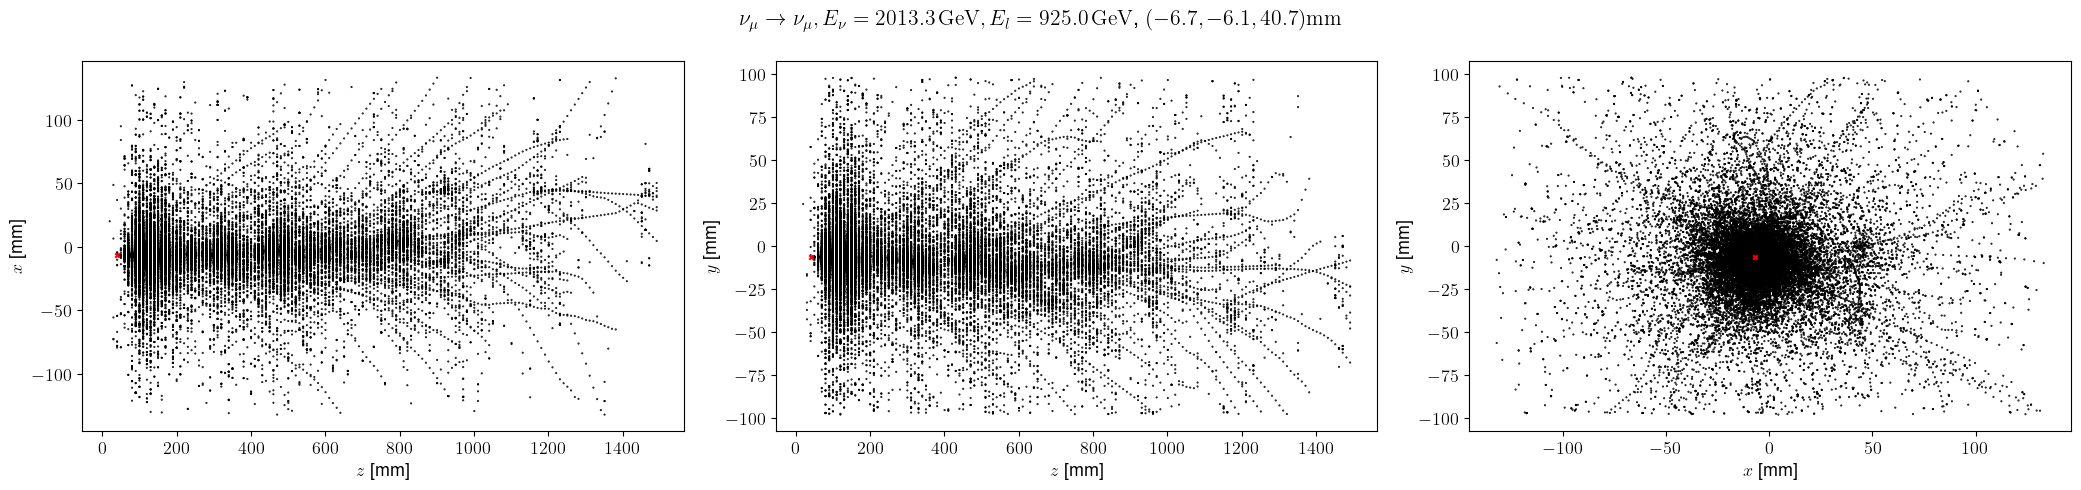

In [ ]:
event_id = 4000
event_df = df.query("event_id == @event_id")
event_truth_df = truth_df.query("event_id == @event_id")
truth = get_truth_particle(event_truth_df)

# event_df.loc[:, "color"] = event_df["hit_pdgc"].apply(get_color_from_pdg)
event_df["color"] = "black"
event_df.loc[event_df["hit_fromPrimaryLepton"] == 1, "color"] = "red"


fig, ax = plt.subplots(ncols=3, figsize=(21, 5))

# zx
ax[0].scatter(event_df["z"], event_df["x"], c=event_df["color"], marker=".", s=1)
ax[0].scatter(
    event_truth_df["vz"],
    event_truth_df["vx"],
    c="red",
    marker="x",
    label="truth Vertex",
    s=10,
)
ax[0].set_xlabel(r"$z$ [mm]")
ax[0].set_ylabel(r"$x$ [mm]")

# zy
ax[1].scatter(event_df["z"], event_df["y"], c=event_df["color"], marker=".", s=1)
ax[1].scatter(
    event_truth_df["vz"],
    event_truth_df["vy"],
    c="red",
    marker="x",
    label="truth Vertex",
    s=10,
)
ax[1].set_xlabel(r"$z$ [mm]")
ax[1].set_ylabel(r"$y$ [mm]")

# xy
ax[2].scatter(event_df["x"], event_df["y"], c=event_df["color"], marker=".", s=1)
ax[2].scatter(
    event_truth_df["vx"],
    event_truth_df["vy"],
    c="red",
    marker="x",
    label="truth Vertex",
    s=10,
)
ax[2].set_xlabel(r"$x$ [mm]")
ax[2].set_ylabel(r"$y$ [mm]")

fig.suptitle(truth.get_latex_title())


# for i in event_df["hit_pdgc"].unique():
#     color = get_color_from_pdg(i)
#     label = get_label_from_pdg(i)
#     if color != "white":
#         ax[0].scatter(
#             [],
#             [],
#             c=color,
#             label=f"${label}$",
#             s=10,
#         )
# ax[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
import 